In [7]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

from IPython.display import display, Image

In [16]:
class AgentState(TypedDict):
    name: str
    age: str
    skils: List[str]
    output: str

In [17]:
def first_node(state: AgentState) -> AgentState:
    state["output"] = f"Hi {state['name']}."
    return state

def second_node(state: AgentState) -> AgentState:
    state["output"] += f" You are {state['age']} years old."
    return state

def third_node(state: AgentState) -> AgentState:
    state["output"] += f" Your skills are {', '.join(state['skils'])}."
    return state

In [18]:
graph = StateGraph(AgentState)

graph.add_node("personalize", first_node)
graph.add_node("age_description", second_node)
graph.add_node("skills_description", third_node)

graph.set_entry_point("personalize")
graph.add_edge("personalize", "age_description")
graph.add_edge("age_description", "skills_description")
graph.set_finish_point("skills_description")

app = graph.compile()

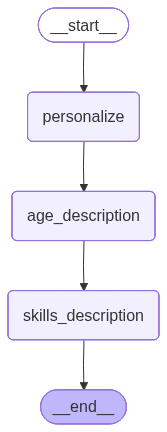

In [19]:
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
result = app.invoke({"name": "Alice", "age": "30", "skils": ["Python", "JavaScript"]})
print(result["output"])

Hi Alice. You are 30 years old. Your skills are Python, JavaScript.


Hi Alice. You are 30 years old. Your skills are Python, JavaScript.
